### Overview

## Import Libraries

In [2]:
#Import Standard Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier

## Data Preprocessing

In [3]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [4]:
# Get Data Ready
data_file = "features_300ms_150ms_overlap.csv"
music_data = pd.read_csv(data_file)
music_data

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,300,0.820354,0.022998,0.141991,0.010220,1773.838925,438338.716796,2367.591548,77382.577395,...,34.716759,-8.558198,36.560204,0.433451,24.618813,-5.878705,45.574993,-10.892500,47.030720,blues
1,blues.00001.wav,300,0.716320,0.044223,0.147373,0.009406,2148.145299,252431.482835,2263.753810,135025.397437,...,42.564156,-12.492635,83.172112,-2.281379,34.923225,-5.373457,36.997662,-8.973206,52.851116,blues
2,blues.00002.wav,300,0.624650,0.050467,0.191377,0.003466,2049.022054,104157.843550,1923.581746,8168.492742,...,70.133766,-15.582106,72.812714,-1.749841,43.884888,-5.319300,30.090799,-10.574518,50.951218,blues
3,blues.00003.wav,300,0.682139,0.044001,0.162216,0.001825,2229.533424,100136.714803,2090.903716,59013.059900,...,68.789055,-14.845062,34.785408,3.200582,38.081703,-6.502884,34.439751,-10.010311,44.665058,blues
4,blues.00004.wav,300,0.547533,0.097336,0.172501,0.000864,2434.913717,109626.588906,2090.908506,75809.998182,...,71.420647,-10.703167,43.099609,5.970252,47.964809,-7.772474,41.583679,-7.409538,40.371536,blues
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200572,rock.20098.wav,300,0.734123,0.028219,0.190071,0.002103,1727.590742,345610.214188,1927.301900,170924.061128,...,35.670769,-0.602435,45.425331,3.055514,36.634285,-4.690790,39.660339,-7.668109,41.779305,rock
200573,rock.20099.wav,300,0.670236,0.038048,0.207446,0.000954,2078.777558,232584.591133,2046.169252,127235.288551,...,33.821934,-8.180123,89.212173,2.103449,32.583015,-0.618241,65.927376,-6.041405,42.973103,rock
200574,rock.20100.wav,300,0.581977,0.061297,0.199906,0.001040,2102.580105,35622.752726,1919.052664,62320.620404,...,20.396629,-14.413528,32.151768,0.552173,40.916851,3.789587,36.593746,-4.513898,29.671715,rock
200575,rock.20101.wav,300,0.546039,0.068201,0.195705,0.001995,2174.693698,49751.526481,2001.873376,75464.591633,...,29.443493,-10.898533,53.397324,-3.101555,29.256279,-0.597299,34.534416,-4.171192,35.655727,rock


In [5]:
# Remove unnecessary Fields
music_data.drop(labels=["filename"],inplace=True, axis=1)
music_data

,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,300,0.820354,0.022998,0.141991,0.010220,1773.838925,438338.716796,2367.591548,77382.577395,4359.645433,...,34.716759,-8.558198,36.560204,0.433451,24.618813,-5.878705,45.574993,-10.892500,47.030720,blues
1,300,0.716320,0.044223,0.147373,0.009406,2148.145299,252431.482835,2263.753810,135025.397437,4705.833083,...,42.564156,-12.492635,83.172112,-2.281379,34.923225,-5.373457,36.997662,-8.973206,52.851116,blues
2,300,0.624650,0.050467,0.191377,0.003466,2049.022054,104157.843550,1923.581746,8168.492742,3862.725361,...,70.133766,-15.582106,72.812714,-1.749841,43.884888,-5.319300,30.090799,-10.574518,50.951218,blues
3,300,0.682139,0.044001,0.162216,0.001825,2229.533424,100136.714803,2090.903716,59013.059900,4409.337440,...,68.789055,-14.845062,34.785408,3.200582,38.081703,-6.502884,34.439751,-10.010311,44.665058,blues
4,300,0.547533,0.097336,0.172501,0.000864,2434.913717,109626.588906,2090.908506,75809.998182,4510.377855,...,71.420647,-10.703167,43.099609,5.970252,47.964809,-7.772474,41.583679,-7.409538,40.371536,blues
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200572,300,0.734123,0.028219,0.190071,0.002103,1727.590742,345610.214188,1927.301900,170924.061128,3327.708083,...,35.670769,-0.602435,45.425331,3.055514,36.634285,-4.690790,39.660339,-7.668109,41.779305,rock
200573,300,0.670236,0.038048,0.207446,0.000954,2078.777558,232584.591133,2046.169252,127235.288551,3958.796575,...,33.821934,-8.180123,89.212173,2.103449,32.583015,-0.618241,65.927376,-6.041405,42.973103,rock
200574,300,0.581977,0.061297,0.199906,0.001040,2102.580105,35622.752726,1919.052664,62320.620404,3872.663762,...,20.396629,-14.413528,32.151768,0.552173,40.916851,3.789587,36.593746,-4.513898,29.671715,rock
200575,300,0.546039,0.068201,0.195705,0.001995,2174.693698,49751.526481,2001.873376,75464.591633,4048.242188,...,29.443493,-10.898533,53.397324,-3.101555,29.256279,-0.597299,34.534416,-4.171192,35.655727,rock


In [6]:
label_mappings = dict(enumerate(music_data['label'].unique()))
label_mappings

{0: 'blues',
 1: 'classical',
 2: 'country',
 3: 'disco',
 4: 'hiphop',
 5: 'jazz',
 6: 'metal',
 7: 'pop',
 8: 'reggae',
 9: 'rock'}

In [7]:
#Converting Label Column to Numerical Field
for k, v in label_mappings.items():
    music_data.loc[(music_data['label'] == v),'label_code'] = k
    
music_data

,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label,label_code
0,300,0.820354,0.022998,0.141991,0.010220,1773.838925,438338.716796,2367.591548,77382.577395,4359.645433,...,-8.558198,36.560204,0.433451,24.618813,-5.878705,45.574993,-10.892500,47.030720,blues,0.0
1,300,0.716320,0.044223,0.147373,0.009406,2148.145299,252431.482835,2263.753810,135025.397437,4705.833083,...,-12.492635,83.172112,-2.281379,34.923225,-5.373457,36.997662,-8.973206,52.851116,blues,0.0
2,300,0.624650,0.050467,0.191377,0.003466,2049.022054,104157.843550,1923.581746,8168.492742,3862.725361,...,-15.582106,72.812714,-1.749841,43.884888,-5.319300,30.090799,-10.574518,50.951218,blues,0.0
3,300,0.682139,0.044001,0.162216,0.001825,2229.533424,100136.714803,2090.903716,59013.059900,4409.337440,...,-14.845062,34.785408,3.200582,38.081703,-6.502884,34.439751,-10.010311,44.665058,blues,0.0
4,300,0.547533,0.097336,0.172501,0.000864,2434.913717,109626.588906,2090.908506,75809.998182,4510.377855,...,-10.703167,43.099609,5.970252,47.964809,-7.772474,41.583679,-7.409538,40.371536,blues,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200572,300,0.734123,0.028219,0.190071,0.002103,1727.590742,345610.214188,1927.301900,170924.061128,3327.708083,...,-0.602435,45.425331,3.055514,36.634285,-4.690790,39.660339,-7.668109,41.779305,rock,9.0
200573,300,0.670236,0.038048,0.207446,0.000954,2078.777558,232584.591133,2046.169252,127235.288551,3958.796575,...,-8.180123,89.212173,2.103449,32.583015,-0.618241,65.927376,-6.041405,42.973103,rock,9.0
200574,300,0.581977,0.061297,0.199906,0.001040,2102.580105,35622.752726,1919.052664,62320.620404,3872.663762,...,-14.413528,32.151768,0.552173,40.916851,3.789587,36.593746,-4.513898,29.671715,rock,9.0
200575,300,0.546039,0.068201,0.195705,0.001995,2174.693698,49751.526481,2001.873376,75464.591633,4048.242188,...,-10.898533,53.397324,-3.101555,29.256279,-0.597299,34.534416,-4.171192,35.655727,rock,9.0


In [8]:
music_data[['label','label_code']]

,label,label_code
0,blues,0.0
1,blues,0.0
2,blues,0.0
3,blues,0.0
4,blues,0.0
...,...,...
200572,rock,9.0
200573,rock,9.0
200574,rock,9.0
200575,rock,9.0


In [9]:
music_data.dtypes

length                       int64
chroma_stft_mean           float64
chroma_stft_var            float64
rms_mean                   float64
rms_var                    float64
spectral_centroid_mean     float64
spectral_centroid_var      float64
spectral_bandwidth_mean    float64
spectral_bandwidth_var     float64
rolloff_mean               float64
rolloff_var                float64
zero_crossing_rate_mean    float64
zero_crossing_rate_var     float64
spectral_contrast_mean     float64
spectral_contrast_var      float64
spectral_flatness_mean     float64
spectral_flatness_var      float64
tempo                      float64
mfcc1_mean                 float64
mfcc1_var                  float64
mfcc2_mean                 float64
mfcc2_var                  float64
mfcc3_mean                 float64
mfcc3_var                  float64
mfcc4_mean                 float64
mfcc4_var                  float64
mfcc5_mean                 float64
mfcc5_var                  float64
mfcc6_mean          

In [11]:
#Fixed in data preprocessing
#music_data['tempo'] = music_data['tempo'].str[1:-1].astype(float)

In [12]:
# Split data into train/test datasets
from sklearn.model_selection import train_test_split

## Create Models 

### Random Forest (75.64% Accuracy)

#### Models Ran
 - Accuracy (n_estimators = 1000, criterion = gini) = 0.7564064213780037 - Best

In [31]:
# Create Random Forest Model
ml_randomforest = RandomForestClassifier(n_estimators=1000)

# Train Random Forest
# Create X (Features)
rfX = music_data.drop(["label", "label_code"], axis=1)

# Create Y (Labels)
rfY = music_data['label']

rfX_train, rfX_test, rfY_train, rfY_test = train_test_split(rfX, rfY, test_size=0.3)
ml_randomforest.fit(rfX_train, rfY_train)

ml_randomforest.score(rfX_test, rfY_test)

0.7564064213780037

In [32]:
rf_preds = ml_randomforest.predict(rfX_test)

print(classification_report(rfY_test, rf_preds))

              precision    recall  f1-score   support

       blues       0.72      0.81      0.76      6092
   classical       0.89      0.95      0.92      6081
     country       0.71      0.64      0.68      6031
       disco       0.66      0.65      0.66      6008
      hiphop       0.80      0.67      0.73      6087
        jazz       0.80      0.84      0.82      5980
       metal       0.80      0.91      0.85      5917
         pop       0.76      0.87      0.81      6028
      reggae       0.68      0.70      0.69      5958
        rock       0.72      0.52      0.60      5992

    accuracy                           0.76     60174
   macro avg       0.75      0.76      0.75     60174
weighted avg       0.75      0.76      0.75     60174



In [46]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
label_encoder = LabelEncoder()
label_encoder.fit_transform(music_data["label"]) 

array([0, 0, 0, ..., 9, 9, 9])

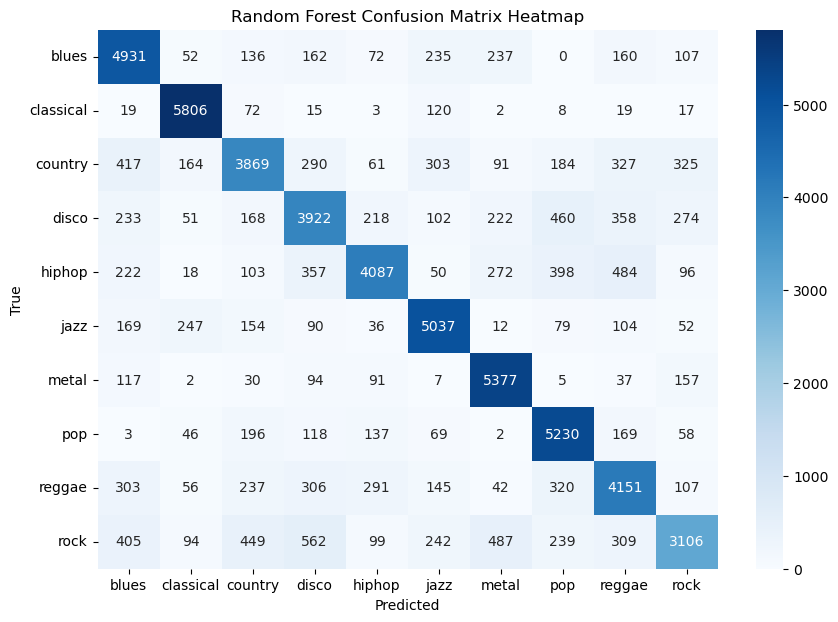

In [47]:
# confusion_matrix heat map
import seaborn as sns
import matplotlib.pyplot as plt 
cm = confusion_matrix(rfY_test, rf_preds)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Random Forest Confusion Matrix Heatmap')
plt.show()  

In [28]:
# Create Random Forest Model
#max_depth 30 -> 0.7551
#md 20 -> 0.74391
#md = 10
ml2_randomforest = RandomForestClassifier(n_estimators=1000)
ml2_randomforest

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [30]:
ml2_randomforest

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

### XGBoost (84.06% Accuracy)

#### Key for XGBoost Labels
 0.0 (blues)
 1.0 (classical)
 2.0 (country)
 3.0 (disco)
 4.0 (hiphop)
 5.0 (jazz)
 6.0 (metal)
 7.0 (pop)
 8.0 (reggae)
 9.0 (rock)
 

#### Models Ran
- n_estimators=1000, max_depth=6, learning_rate=0.3: 0.8406122245488085 - Best


In [33]:
# Create and train XGBoost model w/ default parameters
ml_xgboost = xgb.XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.3) #n_estimators=100, max_depth=3, learning_rate=0.1

# Train XGBoost - Looks like XGBoost doesn't work with categorical data only numerical
# Create X (Features)
xgbX = music_data.drop(["label", "label_code"], axis=1)

# Create Y (Labels)
xgbY = music_data['label_code']

xgbX_train, xgbX_test, xgbY_train, xgbY_test = train_test_split(xgbX, xgbY, test_size=0.3)
ml_xgboost.fit(xgbX_train, xgbY_train)

xgb_preds = ml_xgboost.predict(xgbX_test)

ml_xgboost.score(xgbX_test, xgbY_test)

0.8406122245488085

In [34]:
print(classification_report(xgbY_test, xgb_preds))

              precision    recall  f1-score   support

         0.0       0.86      0.86      0.86      6033
         1.0       0.94      0.97      0.96      6017
         2.0       0.77      0.79      0.78      5944
         3.0       0.76      0.76      0.76      6057
         4.0       0.84      0.80      0.82      6042
         5.0       0.90      0.91      0.90      6035
         6.0       0.90      0.92      0.91      6052
         7.0       0.88      0.88      0.88      5973
         8.0       0.81      0.81      0.81      5957
         9.0       0.75      0.71      0.73      6064

    accuracy                           0.84     60174
   macro avg       0.84      0.84      0.84     60174
weighted avg       0.84      0.84      0.84     60174



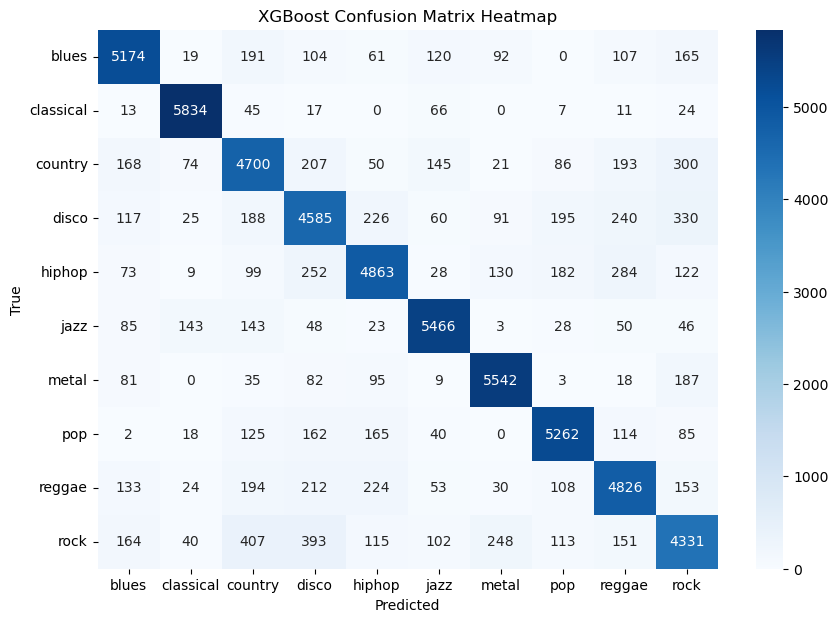

In [49]:
# confusion_matrix heat map
import seaborn as sns
import matplotlib.pyplot as plt 
cm = confusion_matrix(xgbY_test, xgb_preds)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('XGBoost Confusion Matrix Heatmap')
plt.show()  

In [21]:
# Create and train XGBoost model w/ default parameters
ml_xgboost_2 = xgb.XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.3) #n_estimators=100, max_depth=3, learning_rate=0.1

# Train XGBoost
# Create X (Features)
xgbX2 = music_data.drop(["label", "label_code"], axis=1)

# Create Y (Labels)
xgbY2 = music_data['label_code']

xgbX2_train, xgbX2_test, xgbY2_train, xgbY2_test = train_test_split(xgbX2, xgbY2, test_size=0.3)
ml_xgboost_2.fit(xgbX2_train, xgbY2_train)

xgb_preds2 = ml_xgboost_2.predict(xgbX2_test)

ml_xgboost_2.score(xgbX2_test, xgbY2_test)

0.8414597666766378

In [20]:
ml_xgboost_2

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Optional[float]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[str], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load